# 🤖 Entrenamiento - MobileNetV2 sobre PlantVillage (Color)

In [1]:
import torch

print("CUDA disponible:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Dispositivo:", torch.cuda.get_device_name(0))


CUDA disponible: True
Dispositivo: NVIDIA GeForce RTX 3050 Laptop GPU


In [2]:
import pandas as pd
import os
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import torch.nn as nn
import torch.optim as optim
import yaml
import numpy as np


In [3]:
# Leer configuración
with open("../config.yaml", "r") as f:
    config = yaml.safe_load(f)

batch_size = config["modelo"]["batch_size"]
image_size = config["modelo"]["tamaño_imagen"]
num_epochs = config["modelo"]["epochs"]
lr = config["modelo"]["learning_rate"]


In [4]:
class PlantDataset(Dataset):
    def __init__(self, csv_path, transform=None):
        self.data = pd.read_csv(csv_path)
        self.transform = transform
        self.classes = sorted(self.data["clase_nombre"].unique())
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        image_path = row["imagen_rgb"]
        label = self.class_to_idx[row["clase_nombre"]]
        image = Image.open(image_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label


In [5]:
transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_ds = PlantDataset("../data/train.csv", transform=transform)
val_ds = PlantDataset("../data/val.csv", transform=transform)
test_ds = PlantDataset("../data/test.csv", transform=transform)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size)
test_loader = DataLoader(test_ds, batch_size=batch_size)

num_classes = len(train_ds.classes)
print(f"Clases: {train_ds.classes}")


Clases: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___T

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")
model = models.mobilenet_v2(pretrained=True)
model.classifier[1] = nn.Linear(model.last_channel, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

train_losses, val_losses = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    train_losses.append(running_loss / len(train_loader))

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
    val_losses.append(val_loss / len(val_loader))

    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_losses[-1]:.4f} - Val Loss: {val_losses[-1]:.4f}")


Usando dispositivo: cuda


c:\Users\Pablo\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Pablo\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/20 - Train Loss: 0.9936 - Val Loss: 0.6001
Epoch 2/20 - Train Loss: 0.4010 - Val Loss: 0.3031
Epoch 3/20 - Train Loss: 0.3389 - Val Loss: 0.3196
Epoch 4/20 - Train Loss: 0.2341 - Val Loss: 0.3991
Epoch 5/20 - Train Loss: 0.2252 - Val Loss: 0.2605
Epoch 6/20 - Train Loss: 0.1835 - Val Loss: 0.2602
Epoch 7/20 - Train Loss: 0.2664 - Val Loss: 0.3314
Epoch 8/20 - Train Loss: 0.2093 - Val Loss: 0.2871
Epoch 9/20 - Train Loss: 0.1553 - Val Loss: 0.2022
Epoch 10/20 - Train Loss: 0.1179 - Val Loss: 0.2084
Epoch 11/20 - Train Loss: 0.1538 - Val Loss: 0.2221
Epoch 12/20 - Train Loss: 0.0769 - Val Loss: 0.2511
Epoch 13/20 - Train Loss: 0.0730 - Val Loss: 0.2291
Epoch 14/20 - Train Loss: 0.0580 - Val Loss: 0.1753
Epoch 15/20 - Train Loss: 0.0934 - Val Loss: 0.2169
Epoch 16/20 - Train Loss: 0.0937 - Val Loss: 0.2635
Epoch 17/20 - Train Loss: 0.0787 - Val Loss: 0.3537
Epoch 18/20 - Train Loss: 0.0505 - Val Loss: 0.2633
Epoch 19/20 - Train Loss: 0.1405 - Val Loss: 0.3635
Epoch 20/20 - Train L

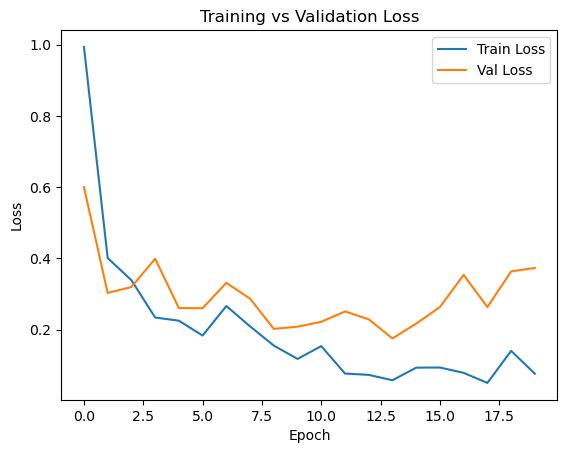

In [7]:
os.makedirs("../models", exist_ok=True)
torch.save(model.state_dict(), "../models/modelo_final.pth")

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.savefig("../results/loss_curve.png")
plt.show()


In [8]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=train_ds.classes))


                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       1.00      0.67      0.80        15
                                 Apple___Black_rot       0.88      1.00      0.94        15
                          Apple___Cedar_apple_rust       1.00      0.93      0.97        15
                                   Apple___healthy       1.00      0.87      0.93        15
                               Blueberry___healthy       0.94      1.00      0.97        15
          Cherry_(including_sour)___Powdery_mildew       0.94      1.00      0.97        15
                 Cherry_(including_sour)___healthy       0.83      1.00      0.91        15
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.93      0.87      0.90        15
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00        15
               Corn_(maize)___Northern_Leaf_Blight       0.88      1.00      0.